In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [2]:
df= pd.read_csv('/content/CC GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.shape

(8950, 18)

In [ ]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [4]:
df['CREDIT_LIMIT']= df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS']= df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

<Axes: >

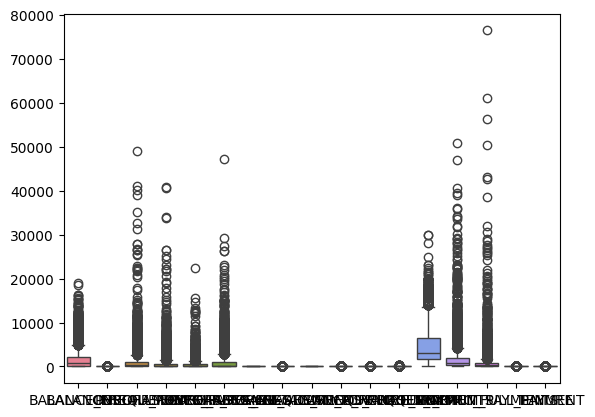

In [5]:
sns.boxplot(df)

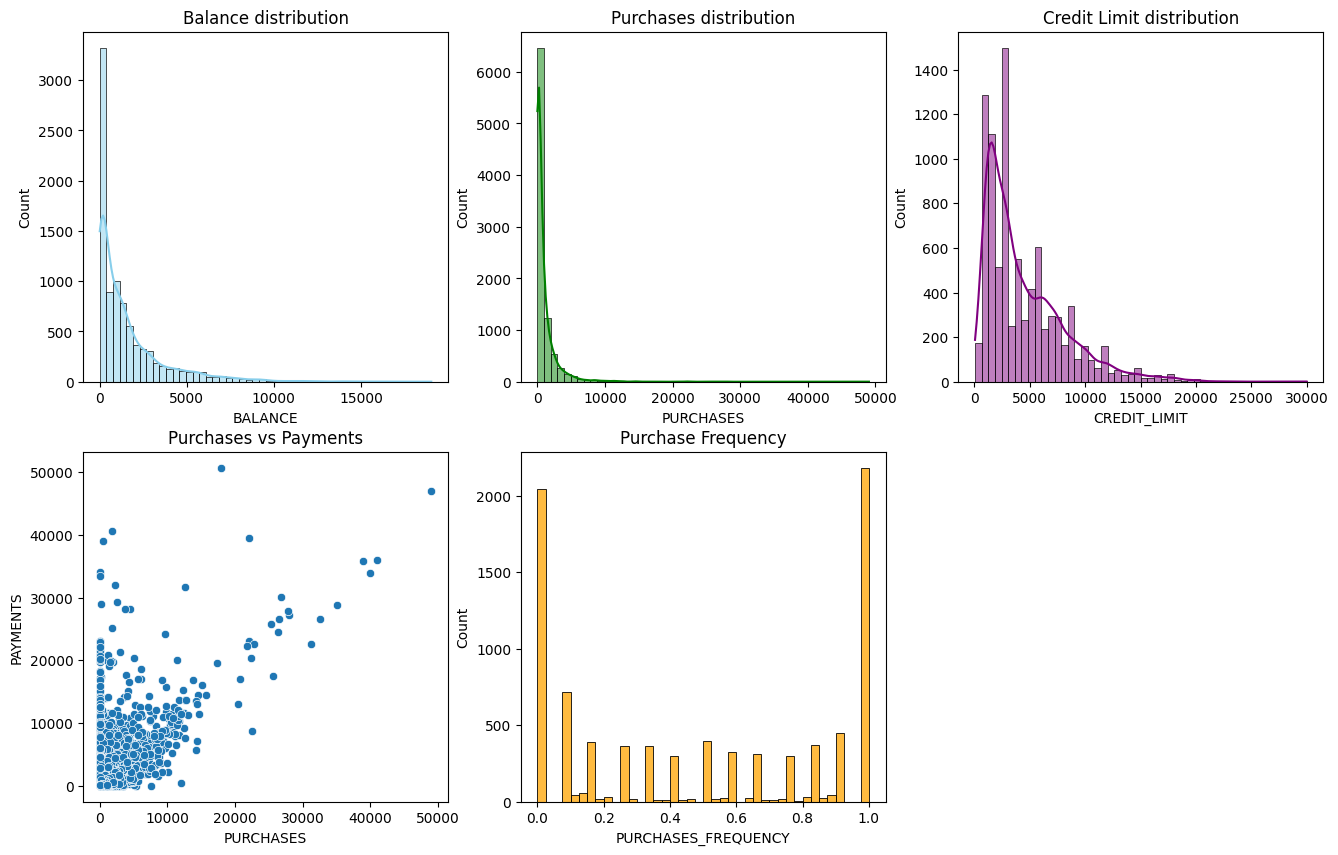

In [6]:
plt.figure(figsize=(16,10))
plt.subplot(2,3,1)
sns.histplot(df["BALANCE"], bins=50, kde=True, color="skyblue")
plt.title("Balance distribution")

plt.subplot(2,3,2)
sns.histplot(df["PURCHASES"], bins=50, kde=True, color="green")
plt.title("Purchases distribution")

plt.subplot(2,3,3)
sns.histplot(df["CREDIT_LIMIT"], bins=50, kde=True, color="purple")
plt.title("Credit Limit distribution")

plt.subplot(2,3,4)
sns.scatterplot(x=df["PURCHASES"], y=df["PAYMENTS"])
plt.title("Purchases vs Payments")

plt.subplot(2,3,5)
sns.histplot(df["PURCHASES_FREQUENCY"], bins=40, color="orange")
plt.title("Purchase Frequency")
plt.show()

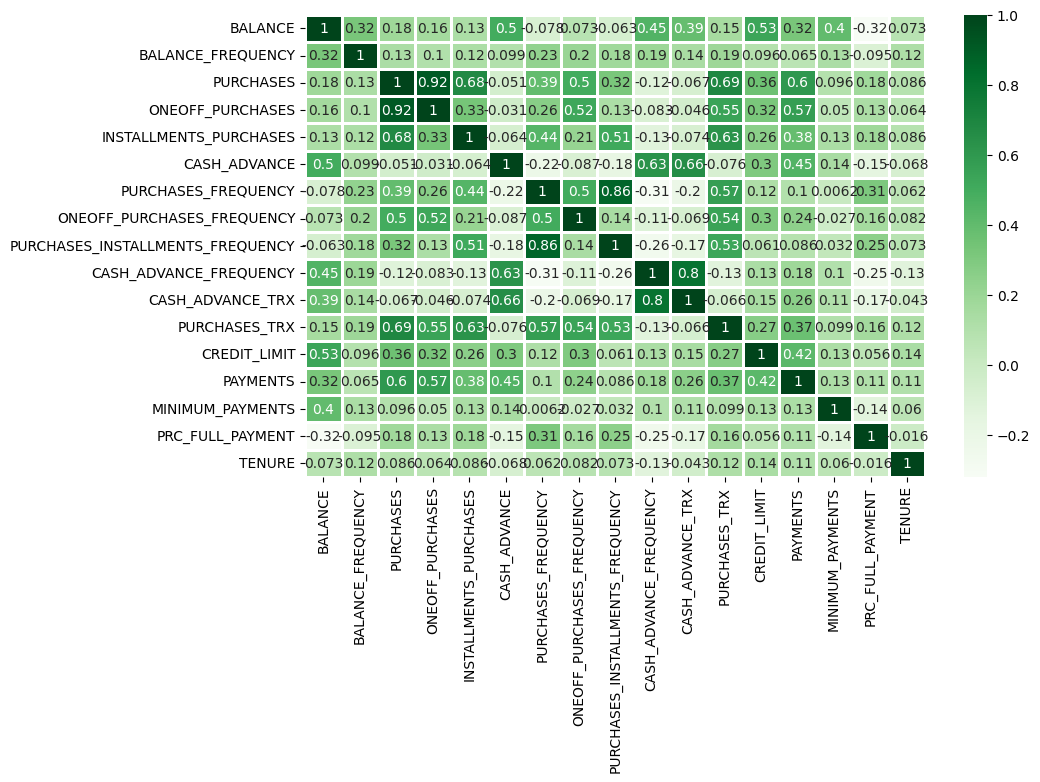

In [7]:
plt.figure(figsize= (10,6))
sns.heatmap(df.drop(['CUST_ID'], axis=1).corr(), annot=True, linewidths=1, cmap='Greens')
plt.show()

In [8]:
df= df.drop(["CUST_ID"], axis=1)

In [9]:
df_fe = df.copy()
one = 1

df_fe["PURCHASES_PER_TRX"] = df_fe["PURCHASES"] / (df_fe["PURCHASES_TRX"] + one)
df_fe["CASH_ADVANCE_PER_TRX"] = df_fe["CASH_ADVANCE"] / (df_fe["CASH_ADVANCE_TRX"] + one)
df_fe["PAYMENT_TO_BALANCE"] = df_fe["PAYMENTS"] / (df_fe["BALANCE"] + one)
df_fe["MINPAY_TO_BALANCE"] = df_fe["MINIMUM_PAYMENTS"] / (df_fe["BALANCE"] + one)
df_fe["CASH_ADVANCE_SHARE"] = df_fe["CASH_ADVANCE"] / (df_fe["PURCHASES"] + df_fe["CASH_ADVANCE"] + one)
df_fe["INSTALLMENT_SHARE"] = df_fe["INSTALLMENTS_PURCHASES"] / (df_fe["PURCHASES"] + one)
df_fe["ONEOFF_SHARE"] = df_fe["ONEOFF_PURCHASES"] / (df_fe["PURCHASES"] + one)

df_fe[["PURCHASES_PER_TRX","CASH_ADVANCE_PER_TRX","PAYMENT_TO_BALANCE","CASH_ADVANCE_SHARE","INSTALLMENT_SHARE","ONEOFF_SHARE"]].describe().T

,count,mean,std,min,25%,50%,75%,max
PURCHASES_PER_TRX,8950.0,58.129748,107.141354,0.0,9.818229,35.872548,68.913654,4486.250000
CASH_ADVANCE_PER_TRX,8950.0,146.634111,316.148808,0.0,0.000000,0.000000,187.083026,7418.225705
PAYMENT_TO_BALANCE,8950.0,16.120941,205.549987,0.0,0.329309,1.400489,7.532226,14229.882480
CASH_ADVANCE_SHARE,8950.0,0.378811,0.442150,0.0,0.000000,0.000000,0.950476,0.999962
INSTALLMENT_SHARE,8950.0,0.400698,0.849339,0.0,0.000000,0.185036,0.969317,66.950000
ONEOFF_SHARE,8950.0,0.377199,0.423428,0.0,0.000000,0.109925,0.871232,1.798389


In [10]:
df_log = df_fe.copy()

for col in df_log.columns:
    df_log[col] = np.log1p(df_log[col])

In [ ]:
# from sklearn.preprocessing import RobustScaler
# scaler = RobustScaler()
# x_scaled = scaler.fit_transform(df_log)

In [14]:
scaler= StandardScaler()
x_scaled= scaler.fit_transform(df_log)


In [15]:
pd.DataFrame(x_scaled).describe().round(4)

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
count,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,...,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000
mean,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,...,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,...,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001
min,-3.0606,-4.1724,-1.6799,-0.9871,-1.0875,-0.9307,-1.3028,-0.7325,-0.9583,-0.7244,...,-5.0408,-0.5564,-4.4014,-1.6720,-0.9285,-1.0605,-0.8541,-0.8759,-0.9398,-0.9196
25%,-0.6456,0.1080,-0.4097,-0.9871,-1.0875,-0.9307,-1.0142,-0.7325,-0.9583,-0.7244,...,-0.6577,-0.5564,0.3473,-0.3556,-0.9285,-0.8254,-0.5799,-0.8759,-0.9398,-0.9196
50%,0.3039,0.4927,0.3404,0.1415,0.3722,-0.9307,0.1594,-0.3630,-0.4113,-0.7244,...,-0.1443,-0.5564,0.3473,0.3223,-0.9285,-0.3374,-0.4305,-0.8759,-0.3802,-0.5702
75%,0.7284,0.4927,0.7246,0.9722,0.9081,1.0368,1.0433,0.4785,1.0273,0.5562,...,0.6459,0.0747,0.3473,0.6760,1.0125,0.7098,0.1809,1.2770,1.2942,1.1796
max,1.8343,0.4927,2.0231,2.2831,2.1633,2.0868,1.1968,2.4668,1.5011,5.1228,...,4.5542,2.7193,0.3473,2.9768,2.3745,6.8364,5.7443,1.3577,12.9675,2.5279


In [16]:
wcss = []
ss = []

for i in range(2,11):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(x_scaled)
    labels = model.predict(x_scaled)
    ss1 = silhouette_score(x_scaled, labels)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.27896051048525855
0.2445621313657262
0.25289906774794335
0.25466447760196775
0.2515519138977584
0.25113059708379337
0.24238646590111987
0.23906196385821218
0.18939428088080948


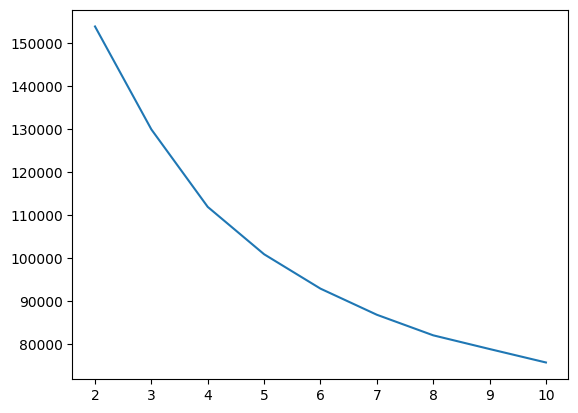

In [17]:
plt.plot(range(2,11), wcss)

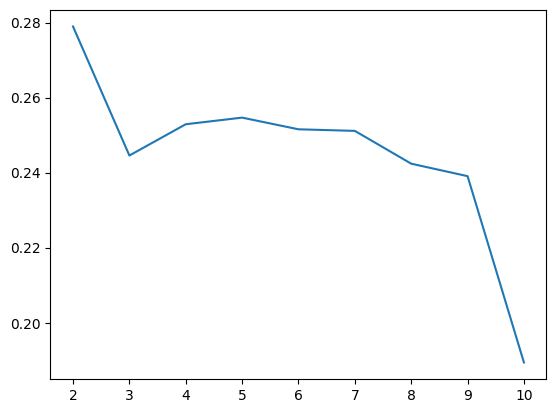

In [18]:
plt.plot(range(2,11), ss)

# **Clustering Model Training**

In [19]:
model = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = model.fit_predict(x_scaled)
df_log["cluster"] = clusters

In [20]:
silhouette_score(x_scaled,clusters)

np.float64(0.2445621313657262)

In [21]:
df_log["cluster"].value_counts()

,count
cluster,
0,3696
1,2703
2,2551


In [22]:
df_cluster = df.copy()
df_cluster["cluster"] = clusters

In [ ]:
# [["BALANCE", "PURCHASES", "CASH_ADVANCE", "ONEOFF_PURCHASES_FREQUENCY", "PURCHASES_INSTALLMENTS_FREQUENCY"]]

In [23]:
df_cluster.groupby("cluster").mean().T

cluster,0,1,2
BALANCE,1920.665651,2312.405957,255.913821
BALANCE_FREQUENCY,0.957866,0.900889,0.735476
PURCHASES,2023.629129,52.820340,531.782289
ONEOFF_PURCHASES,1360.756699,36.666859,68.148644
INSTALLMENTS_PURCHASES,662.994210,16.191095,464.470517
CASH_ADVANCE,757.172021,2192.042554,14.620794
PURCHASES_FREQUENCY,0.705815,0.056006,0.638401
ONEOFF_PURCHASES_FREQUENCY,0.442047,0.025100,0.043255
PURCHASES_INSTALLMENTS_FREQUENCY,0.461323,0.027474,0.581107
CASH_ADVANCE_FREQUENCY,0.108062,0.294875,0.005134


**Cluster 0:** Use card very frequently, Make many purchases, Spend consistently, Pay a large portion of their balance

**Cluster 1:** Rarely use the card for purchases, Mainly withdraw cash advances, Maintain very high outstanding balances, Mostly pay only minimum payments

**Cluster 2:** maintain low balance, but make purchases frequently, more likely to do installment purchases, make small purchases

In [24]:
cluster_labels = {
    0: "High Value Customers",
    1: "Cash Advance Users",
    2: "Installment Users"
}

df_cluster["Customer_Segment"] = df_cluster["cluster"].map(cluster_labels)

df_cluster.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster,Customer_Segment
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2,Installment Users
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1,Cash Advance Users
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0,High Value Customers
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,0,High Value Customers
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0,High Value Customers


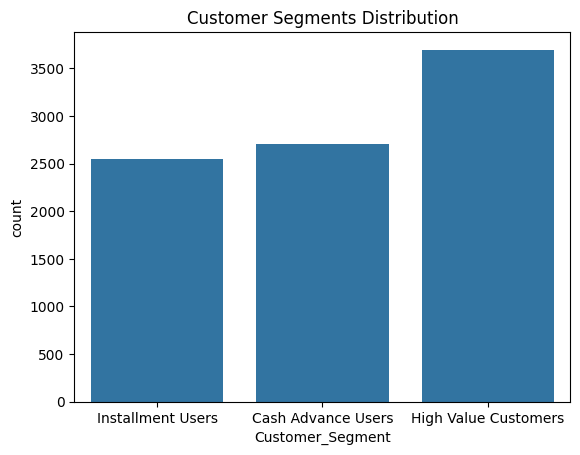

In [25]:
sns.countplot(x="Customer_Segment", data=df_cluster)
plt.title("Customer Segments Distribution")
plt.show()

In [ ]:
# df_cluster.to_csv("Clustered_Credit_Card_General.csv", index=False)

# **Supervised Model training**

In [31]:
X = df_cluster.drop(["cluster", "Customer_Segment"], axis=1)
y = df_cluster["cluster"]

In [32]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [35]:
y_pred = model.predict(x_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9770949720670391

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       768
           1       0.98      0.98      0.98       523
           2       0.98      0.97      0.97       499

    accuracy                           0.98      1790
   macro avg       0.98      0.98      0.98      1790
weighted avg       0.98      0.98      0.98      1790


Confusion Matrix:

[[753   5  10]
 [ 11 511   1]
 [ 11   3 485]]
